# EDA: IndoSum dan NusaX Dataset

Notebook ini melakukan eksplorasi awal (EDA) terhadap dua dataset:
- **IndoSum**: artikel berita Indonesia dengan referensi ringkasan
- **NusaX**: corpus multibahasa (10 dialek daerah Indonesia)

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

# deteksi lingkungan Kaggle atau lokal
KAGGLE = os.path.exists('/kaggle')
BASE = '/kaggle/input' if KAGGLE else '../dataset'

INDOSUM_DIR = Path(BASE) / 'indosum'
NUSAX_MT_DIR = Path(BASE) / 'nusax/datasets/mt'
NUSAX_LEX_DIR = Path(BASE) / 'nusax/datasets/lexicon'
NUSAX_SENTI_DIR = Path(BASE) / 'nusax/datasets/sentiment'

print(f"Kaggle: {KAGGLE}")
print(f"IndoSum ada: {INDOSUM_DIR.exists()}")
print(f"NusaX MT ada: {NUSAX_MT_DIR.exists()}")

Kaggle: False
IndoSum ada: True
NusaX MT ada: True


## 1. IndoSum Dataset

In [2]:
def flatten_tokens(nested):
    """Mengubah struktur token bersarang menjadi teks biasa."""
    if not nested:
        return ""
    # paragraf: list[list[list[str]]] -> cek apakah elemen pertama dari elemen pertama adalah list
    if isinstance(nested[0][0], list):
        sentences = []
        for para in nested:
            for sent in para:
                sentences.append(" ".join(sent))
        return ". ".join(sentences)
    else:
        # summary: list[list[str]]
        return " ".join(" ".join(sent) for sent in nested)


def load_indosum(data_dir, split, fold=1):
    """Memuat satu split IndoSum dan mengembalikan list dict {text, summary, category}."""
    path = Path(data_dir) / f"{split}.0{fold}.jsonl"
    records = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            r = json.loads(line)
            records.append({
                "text":     flatten_tokens(r["paragraphs"]),
                "summary":  flatten_tokens(r["summary"]),
                "category": r["category"],
                "id":       r["id"],
            })
    return records

In [3]:
train_data = load_indosum(INDOSUM_DIR, "train", fold=1)
dev_data   = load_indosum(INDOSUM_DIR, "dev",   fold=1)
test_data  = load_indosum(INDOSUM_DIR, "test",  fold=1)

print(f"Jumlah data  - Train: {len(train_data)}, Dev: {len(dev_data)}, Test: {len(test_data)}")
print()
print("Contoh artikel:")
print(train_data[0]["text"][:300])
print()
print("Contoh ringkasan:")
print(train_data[0]["summary"])
print("Kategori:", train_data[0]["category"])

Jumlah data  - Train: 14262, Dev: 750, Test: 3762

Contoh artikel:
Jakarta , CNN Indonesia - - Dokter Ryan Thamrin , yang terkenal lewat acara Dokter Oz Indonesia , meninggal dunia pada Jumat ( 4 / 8 ) dini hari .. Dokter Lula Kamal yang merupakan selebriti sekaligus rekan kerja Ryan menyebut kawannya itu sudah sakit sejak setahun yang lalu .. Lula menuturkan , sak

Contoh ringkasan:
Dokter Lula Kamal yang merupakan selebriti sekaligus rekan kerja Ryan Thamrin menyebut kawannya itu sudah sakit sejak setahun yang lalu . Lula menuturkan , sakit itu membuat Ryan mesti vakum dari semua kegiatannya , termasuk menjadi pembawa acara Dokter Oz Indonesia . Kondisi itu membuat Ryan harus kembali ke kampung halamannya di Pekanbaru , Riau untuk menjalani istirahat .
Kategori: tajuk utama


In [4]:
def word_count(text):
    return len(text.split())

splits = [("train", train_data), ("dev", dev_data), ("test", test_data)]
print(f"{'Split':<8} {'N':>6} {'Avg Teks (kata)':>18} {'Avg Ringkasan (kata)':>22}")
print("-" * 58)
for name, data in splits:
    text_lens = [word_count(r["text"])    for r in data]
    sum_lens  = [word_count(r["summary"]) for r in data]
    print(f"{name:<8} {len(data):>6} {sum(text_lens)/len(text_lens):>18.1f} {sum(sum_lens)/len(sum_lens):>22.1f}")

Split         N    Avg Teks (kata)   Avg Ringkasan (kata)
----------------------------------------------------------
train     14262              346.8                   67.7
dev         750              348.6                   67.7
test       3762              343.3                   67.7


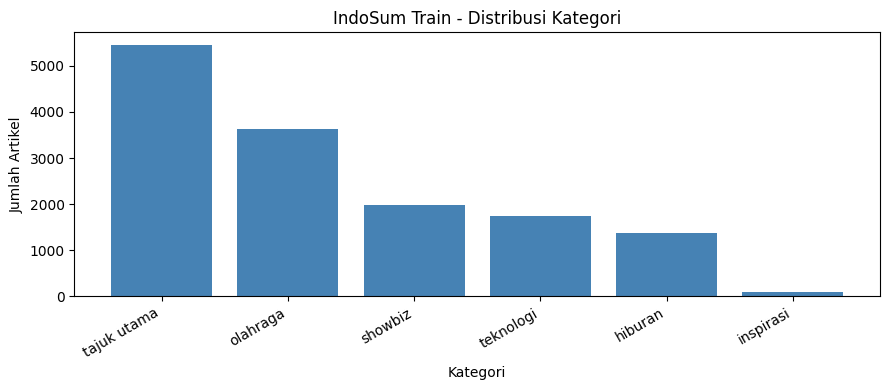

{'tajuk utama': 5454, 'olahraga': 3624, 'showbiz': 1982, 'teknologi': 1734, 'hiburan': 1372, 'inspirasi': 96}


In [5]:
# Distribusi kategori pada train set
cats = Counter(r["category"] for r in train_data)
cats_sorted = dict(sorted(cats.items(), key=lambda x: -x[1]))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(cats_sorted.keys(), cats_sorted.values(), color="steelblue")
ax.set_title("IndoSum Train - Distribusi Kategori")
ax.set_xlabel("Kategori")
ax.set_ylabel("Jumlah Artikel")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
print(cats_sorted)

Rata-rata compression ratio: 0.225
Min: 0.045, Max: 1.455
Artinya: ringkasan rata-rata 22.5% dari panjang artikel


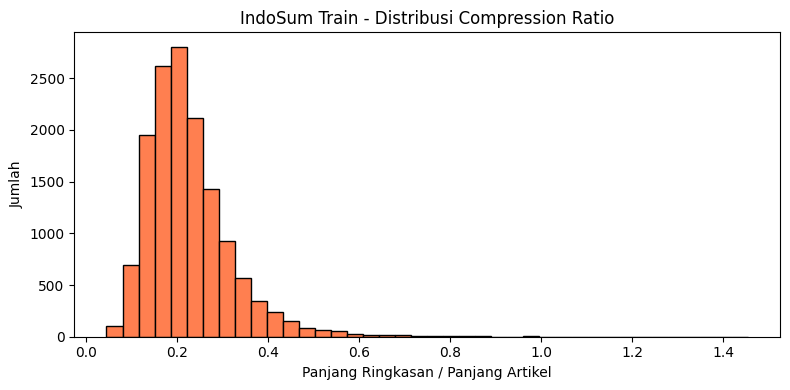

In [6]:
# Compression ratio: panjang ringkasan / panjang artikel
ratios = []
for r in train_data:
    t = word_count(r["text"])
    s = word_count(r["summary"])
    if t > 0:
        ratios.append(s / t)

print(f"Rata-rata compression ratio: {sum(ratios)/len(ratios):.3f}")
print(f"Min: {min(ratios):.3f}, Max: {max(ratios):.3f}")
print(f"Artinya: ringkasan rata-rata {sum(ratios)/len(ratios)*100:.1f}% dari panjang artikel")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ratios, bins=40, edgecolor="black", color="coral")
ax.set_title("IndoSum Train - Distribusi Compression Ratio")
ax.set_xlabel("Panjang Ringkasan / Panjang Artikel")
ax.set_ylabel("Jumlah")
plt.tight_layout()
plt.show()

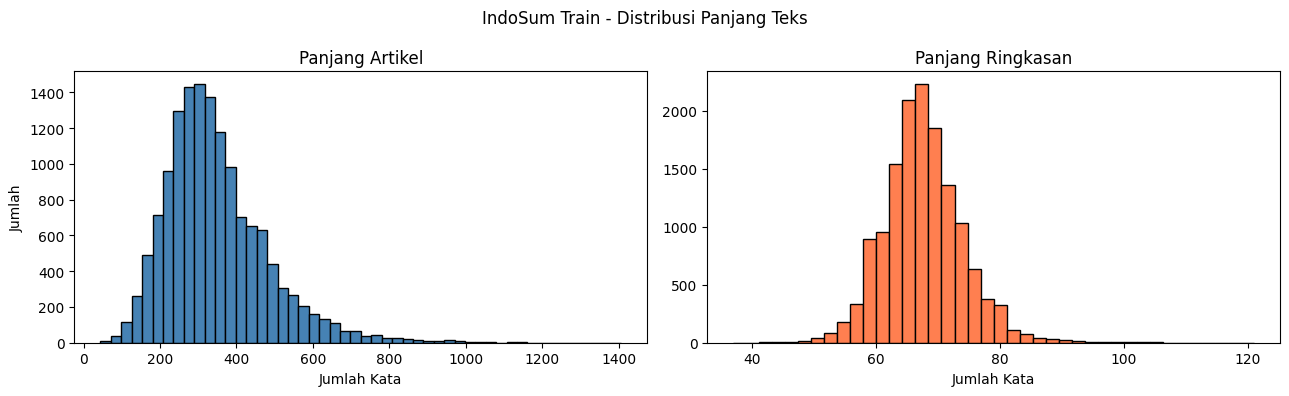

In [7]:
# Distribusi panjang teks dan ringkasan
text_lens = [word_count(r["text"])    for r in train_data]
sum_lens  = [word_count(r["summary"]) for r in train_data]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.hist(text_lens, bins=50, edgecolor="black", color="steelblue")
ax1.set_title("Panjang Artikel")
ax1.set_xlabel("Jumlah Kata")
ax1.set_ylabel("Jumlah")

ax2.hist(sum_lens, bins=40, edgecolor="black", color="coral")
ax2.set_title("Panjang Ringkasan")
ax2.set_xlabel("Jumlah Kata")

plt.suptitle("IndoSum Train - Distribusi Panjang Teks")
plt.tight_layout()
plt.show()

## 2. NusaX Dataset

In [8]:
# Load NusaX Machine Translation (MT) dataset
mt_train = pd.read_csv(NUSAX_MT_DIR / "train.csv")
mt_valid = pd.read_csv(NUSAX_MT_DIR / "valid.csv")
mt_test  = pd.read_csv(NUSAX_MT_DIR / "test.csv")

mt_all = pd.concat([mt_train, mt_valid, mt_test], ignore_index=True)

print(f"NusaX MT - Train: {len(mt_train)}, Valid: {len(mt_valid)}, Test: {len(mt_test)}")
print(f"Kolom tersedia: {mt_all.columns.tolist()}")

NusaX MT - Train: 500, Valid: 100, Test: 400
Kolom tersedia: ['Unnamed: 0', 'indonesian', 'acehnese', 'banjarese', 'english', 'madurese', 'ngaju', 'sundanese', 'balinese', 'buginese', 'javanese', 'minangkabau', 'toba_batak']


In [9]:
# Contoh kalimat per dialek
DIALECTS = ["javanese", "sundanese", "minangkabau", "balinese",
            "banjarese", "buginese", "madurese", "acehnese", "ngaju", "toba_batak"]

print("Contoh kalimat paralel (baris pertama):")
print(f"{'Indonesian':<15}: {mt_all['indonesian'].iloc[0][:80]}")
print()
for d in DIALECTS:
    val = mt_all[d].iloc[0]
    if isinstance(val, str):
        print(f"{d:<15}: {val[:80]}")

Contoh kalimat paralel (baris pertama):
Indonesian     : Nikmati cicilan 0% hingga 12 bulan untuk pemesanan tiket pesawat air asia dengan

javanese       : Nikmatono cicilan 0% sampek 12 sasi dinggo pesen tiket kapal air asia nganggo ke
sundanese      : Nikmati angsuran 0% dugi ka 12 bulan kanggo mesen tiket pasawat air asia nganggo
minangkabau    : Nikmati cicilan 0% sampai 12 bulan untuak pamasanan tiket pisawat air asia jo ka
balinese       : Nikmati cicilan 0% kanti 12 bulan antuk pemesanan tiket pesawat air asia ngangge
banjarese      : Rasai cicilan 0% sampai 12 bulan gasan mamasan tikit pasawat air asia lawan kart
buginese       : pirasai cicilan 0% lettu 12 uleng ko mappesang tike' pesawa' air asia pake kartu
madurese       : Nikmati cecelan 0% sampek 12 bulen ghebey pamessenan karcis kapal air asia bik k
acehnese       : Neumeuseunang ngon neubayeue bacut-bacut angsuran 0% persen sampoe dua blah bule
ngaju          : Mengkeme angsuran nol% sampai  due welas bulan akan pameteh 

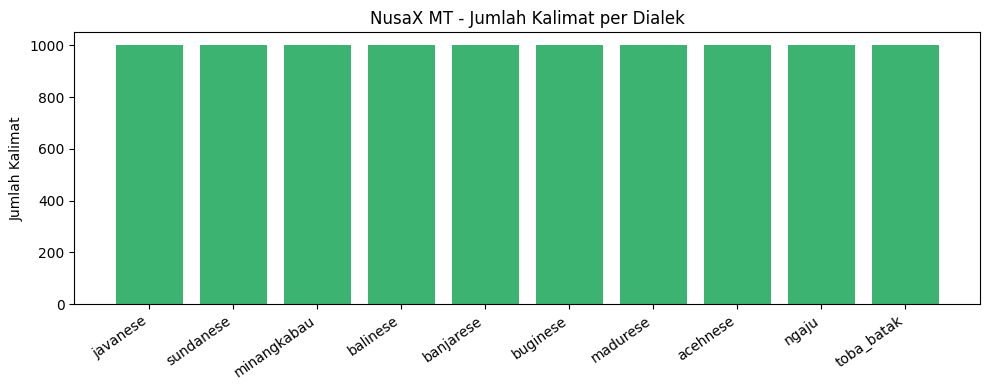

In [10]:
# Distribusi jumlah kalimat per dialek (semua ada 1000 kalimat)
dialect_counts = {d: mt_all[d].notna().sum() for d in DIALECTS}

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(dialect_counts.keys(), dialect_counts.values(), color="mediumseagreen")
ax.set_title("NusaX MT - Jumlah Kalimat per Dialek")
ax.set_ylabel("Jumlah Kalimat")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [11]:
# Rata-rata panjang kalimat per dialek vs Bahasa Indonesia
id_len = mt_all["indonesian"].dropna().apply(lambda x: len(x.split())).mean()
print(f"{'Bahasa':<15} {'Avg Kata':>10}")
print("-" * 28)
print(f"{'Indonesian':<15} {id_len:>10.1f}")
for d in DIALECTS:
    avg = mt_all[d].dropna().apply(lambda x: len(x.split()) if isinstance(x, str) else 0).mean()
    print(f"{d:<15} {avg:>10.1f}")

Bahasa            Avg Kata
----------------------------
Indonesian            23.1
javanese              23.1
sundanese             23.1
minangkabau           23.1
balinese              23.4
banjarese             23.1
buginese              24.5
madurese              23.8
acehnese              23.9
ngaju                 24.8
toba_batak            25.5


In [12]:
# Analisis overlap kosakata antara setiap dialek dan Bahasa Indonesia
def get_vocab(texts):
    vocab = set()
    for t in texts:
        if isinstance(t, str):
            vocab.update(t.lower().split())
    return vocab

id_vocab = get_vocab(mt_all["indonesian"].dropna())

print("Overlap kosakata dialek terhadap Bahasa Indonesia:")
print(f"{'Dialek':<15} {'Overlap':>10} {'Vocab Dialek':>14}")
print("-" * 42)
for d in DIALECTS:
    d_vocab = get_vocab(mt_all[d].dropna())
    if d_vocab:
        overlap = len(id_vocab & d_vocab) / len(d_vocab)
        print(f"{d:<15} {overlap:>10.3f} {len(d_vocab):>14}")

Overlap kosakata dialek terhadap Bahasa Indonesia:
Dialek             Overlap   Vocab Dialek
------------------------------------------
javanese             0.452           6001
sundanese            0.456           5947
minangkabau          0.502           5670
balinese             0.466           6196
banjarese            0.503           5817
buginese             0.232           6439
madurese             0.348           6118
acehnese             0.367           5489
ngaju                0.497           5092
toba_batak           0.317           5900


In [13]:
# Statistik leksikon NusaX
print("Jumlah entri leksikon per bahasa:")
for lex_file in sorted(NUSAX_LEX_DIR.glob("*.csv")):
    lang = lex_file.stem
    df   = pd.read_csv(lex_file)
    print(f"  {lang:<15}: {len(df)} entri")

Jumlah entri leksikon per bahasa:
  acehnese       : 1014 entri
  balinese       : 1063 entri
  banjarese      : 795 entri
  buginese       : 1020 entri
  english        : 2443 entri
  javanese       : 940 entri
  madurese       : 1252 entri
  minangkabau    : 654 entri
  ngaju          : 833 entri
  sundanese      : 995 entri
  toba_batak     : 1662 entri


## Ringkasan Dataset

| Dataset | Split | Jumlah | Avg Teks (kata) | Avg Ringkasan (kata) | Avg Compression |
|---------|-------|--------|-----------------|----------------------|-----------------|
| IndoSum | Train | 14,262 | ~347            | ~68                  | ~0.22           |
| IndoSum | Dev   |    750 | ~347            | ~68                  | ~0.22           |
| IndoSum | Test  |  3,762 | ~347            | ~68                  | ~0.22           |

| Dataset    | Jumlah | Bahasa/Dialek |
|-----------|--------|---------------|
| NusaX MT  | 1,000  | 10 dialek + Indonesia + Inggris |
| NusaX Senti | 12,000 | 12 bahasa |
| NusaX Lexicon | ~11,000 | 10 dialek |

**Kesimpulan:**
- IndoSum cocok untuk melatih model summarization Bahasa Indonesia
- NusaX menyediakan contoh kalimat paralel untuk translasi dialek ke Indonesia
- Overlap kosakata dialek terhadap Indonesia bervariasi (lebih tinggi = lebih mirip)
